<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Import Needed Libraries</h2>
</div>

In [ ]:
import pandas as pd
import nltk
nltk.download('punkt')
import spacy
nlp = spacy.load("en_core_web_sm")
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize , sent_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier , BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import  ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ahmed\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Reading Dataset And Get Info</h2>
</div>

In [351]:
df = pd.read_csv('spam (2).csv', encoding='latin-1')

In [352]:
# Show Sample of Data
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4904,spam,Warner Village 83118 C Colin Farrell in SWAT t...,NaN,NaN,NaN
2127,ham,Tessy..pls do me a favor. Pls convey my birthd...,NaN,NaN,NaN
5044,ham,We have sent JD for Customer Service cum Accou...,NaN,NaN,NaN
852,ham,No da if you run that it activate the full ver...,NaN,NaN,NaN
3872,ham,"Happy or sad , one thing about past is- \Its n...",NaN,NaN,NaN


In [353]:
# Show Shape of Data
print(f"Number of Row : {df.shape[0]}\nNumber of Columns : {df.shape[1]}")

Number of Row : 5572
Number of Columns : 5


In [354]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [355]:
# Check NaN Value
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [356]:
# Describe Numiric Data
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [357]:
pd.DataFrame({'Count':df.shape[0],
              'Null':df.isnull().sum(),
              'Null %':df.isnull().mean() * 100,
              'Cardinality':df.nunique()
})

,Count,Null,Null %,Cardinality
v1,5572,0,0.000000,2
v2,5572,0,0.000000,5169
Unnamed: 2,5572,5522,99.102656,43
Unnamed: 3,5572,5560,99.784637,10
Unnamed: 4,5572,5566,99.892319,5


In [358]:
# Check Dublication
df.duplicated().sum()

403

<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Preprocessing Text</h2>
</div>

## Feature Engineering

In [359]:
# Drop Unncessary Columns & Dublicated Rows
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
df.drop_duplicates(inplace=True)
df.rename(columns={'v1':'Target', 'v2':'Text'}, inplace=True)

In [360]:
df['No_of_Characters'] = df['Text'].apply(len)
df['No_of_Words'] = df['Text'].apply(lambda x:len(word_tokenize(x)))
df['No_of_Sentences'] = df['Text'].apply(lambda x:len(sent_tokenize(x)))
df.head()

,Target,Text,No_of_Characters,No_of_Words,No_of_Sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [361]:
df.describe()

,No_of_Characters,No_of_Words,No_of_Sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [362]:
# New Info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Target            5169 non-null   object
 1   Text              5169 non-null   object
 2   No_of_Characters  5169 non-null   int64 
 3   No_of_Words       5169 non-null   int64 
 4   No_of_Sentences   5169 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 242.3+ KB


<Figure size 1200x800 with 0 Axes>

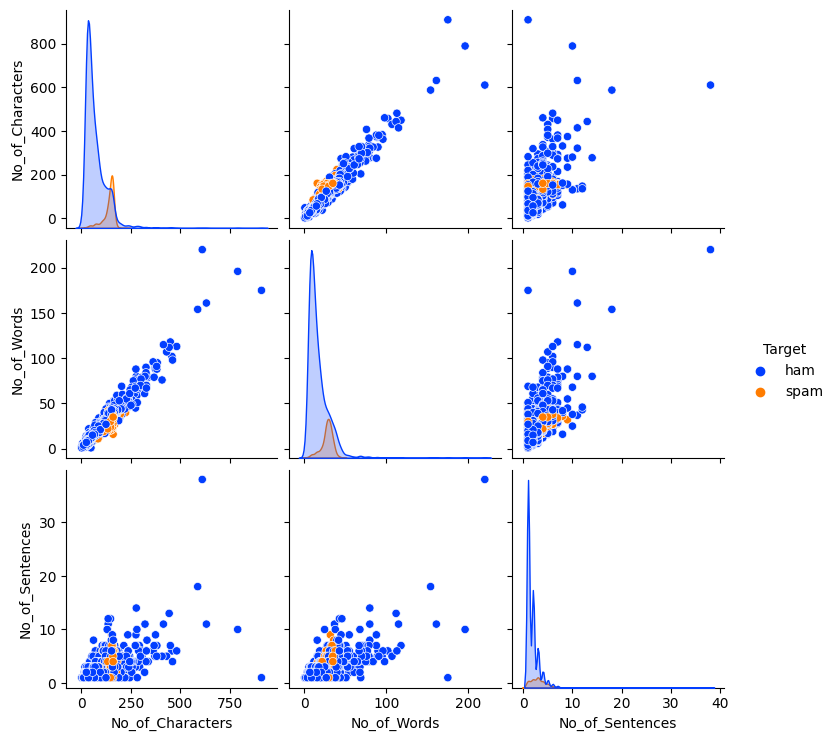

In [363]:
plt.figure(figsize=(12,8))
sns.pairplot(data=df, hue="Target",palette="bright")
plt.show()

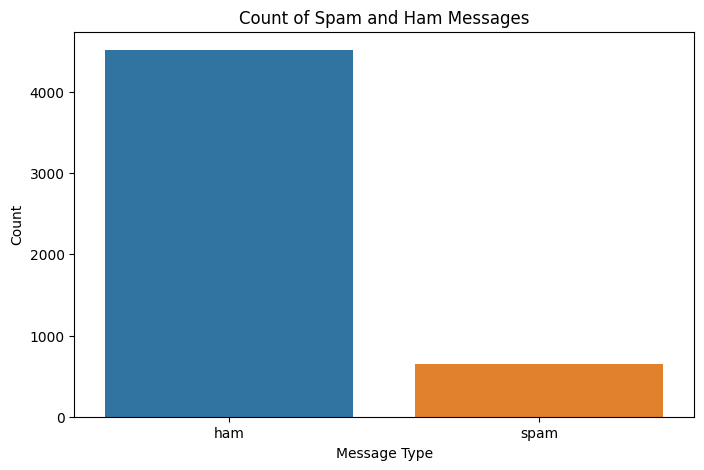

In [364]:
# plot the count of spam and ham messages
plt.figure(figsize=(8, 5))
sns.countplot(x='Target', data=df)
plt.title('Count of Spam and Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

- There Imbalanced Data for spam

## Clean Text

In [365]:
def clean(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    doc = nlp(' '.join(tokens))
    lemmatized = [token.lemma_ for token in doc if token.lemma_ != '-PRON-']

    return ' '.join(lemmatized)


df['cleanded_text'] = df['Text'].apply(lambda x: x.lower())

In [366]:
# Text after Cleaning
df['cleanded_text']

0       go until jurong point, crazy.. available only ...
1                           ok lar... joking wif u oni...
2       free entry in 2 a wkly comp to win fa cup fina...
3       u dun say so early hor... u c already then say...
4       nah i don't think he goes to usf, he lives aro...
                              ...                        
5567    this is the 2nd time we have tried 2 contact u...
5568                will ì_ b going to esplanade fr home?
5569    pity, * was in mood for that. so...any other s...
5570    the guy did some bitching but i acted like i'd...
5571                           rofl. its true to its name
Name: cleanded_text, Length: 5169, dtype: object

<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Model</h2>
</div>

In [333]:
X = df['cleanded_text']
y = df['Target'].map({'ham':0, 'spam':1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [334]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [335]:
# handle the imbalance in the dataset using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

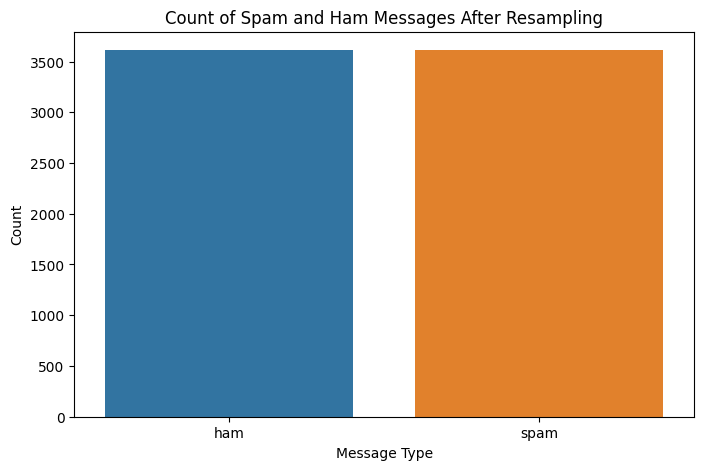

In [336]:
# plot the count of spam and ham messages
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train.map({0:'ham', 1:'spam'}))
plt.title('Count of Spam and Ham Messages After Resampling')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

In [337]:
def train(model ,model_name ,X_train ,y_train ,X_test ,y_test):
    model.fit(X_train,y_train)
    model_train_score = model.score(X_train,y_train)
    model_test_score = model.score(X_test,y_test)
    print(f"{model_name} model score on Training data: {model_train_score * 100}%\n{model_name} model score on Testing data: {model_test_score * 100}%")

def class_report(model ,X_test , y_test):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

#### Logistic Regression

In [338]:
lr = LogisticRegression()
train(lr,"Logistic Regression", X_train, y_train, X_test, y_test)
class_report(lr, X_test, y_test)

Logistic Regression model score on Training data: 99.2388596734016%
Logistic Regression model score on Testing data: 97.77562862669245%
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.93      0.89      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034



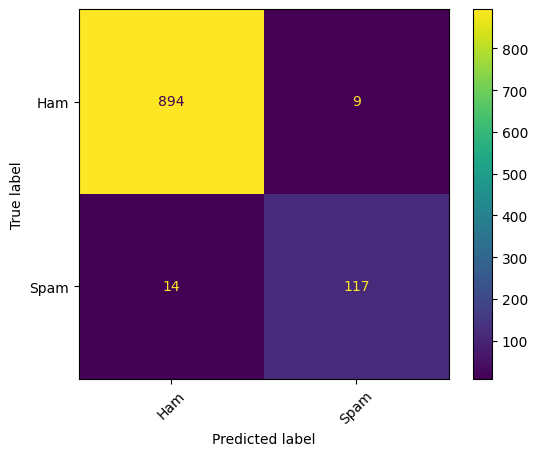

In [339]:
ConfusionMatrixDisplay.from_estimator(lr,
                                       X_test,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Ham', 'Spam']
    );

#### KNN

In [342]:
knn = KNeighborsClassifier()
train(knn,"KNN", X_train, y_train, X_test, y_test)
class_report(knn, X_test, y_test)

KNN model score on Training data: 99.94464433988375%
KNN model score on Testing data: 94.97098646034816%
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.99      0.61      0.75       131

    accuracy                           0.95      1034
   macro avg       0.97      0.80      0.86      1034
weighted avg       0.95      0.95      0.94      1034



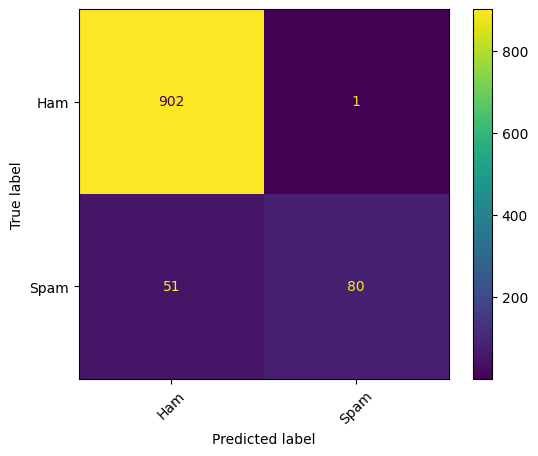

In [343]:
ConfusionMatrixDisplay.from_estimator(knn,
                                       X_test,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Ham', 'Spam']
    );

#### Bagging

In [344]:
bagg_model = BaggingClassifier(n_estimators=40)
train(bagg_model,"Bagging", X_train, y_train, X_test, y_test)
class_report(bagg_model, X_test, y_test)

Bagging model score on Training data: 99.9584832549128%
Bagging model score on Testing data: 96.42166344294004%
              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98       903
        Spam       0.85      0.87      0.86       131

    accuracy                           0.96      1034
   macro avg       0.92      0.92      0.92      1034
weighted avg       0.96      0.96      0.96      1034



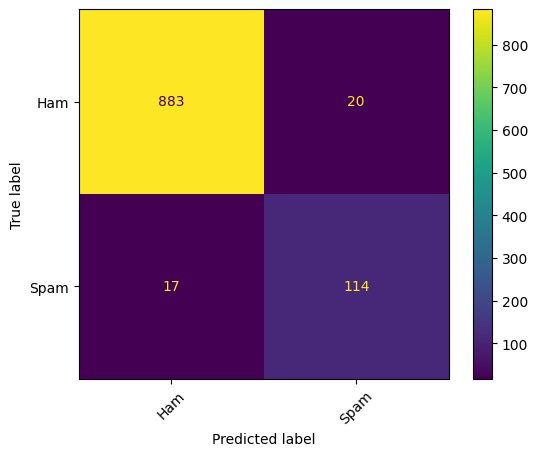

In [345]:
ConfusionMatrixDisplay.from_estimator(bagg_model,
                                       X_test,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Ham', 'Spam']
    );

#### Gradient Boosting

In [346]:
gb_model = GradientBoostingClassifier(n_estimators=50)
train(gb_model,"Boosting", X_train, y_train, X_test, y_test)
class_report(gb_model, X_test, y_test)

Boosting model score on Training data: 97.74425685026293%
Boosting model score on Testing data: 95.55125725338492%
              precision    recall  f1-score   support

         Ham       0.97      0.98      0.97       903
        Spam       0.83      0.82      0.82       131

    accuracy                           0.96      1034
   macro avg       0.90      0.90      0.90      1034
weighted avg       0.96      0.96      0.96      1034



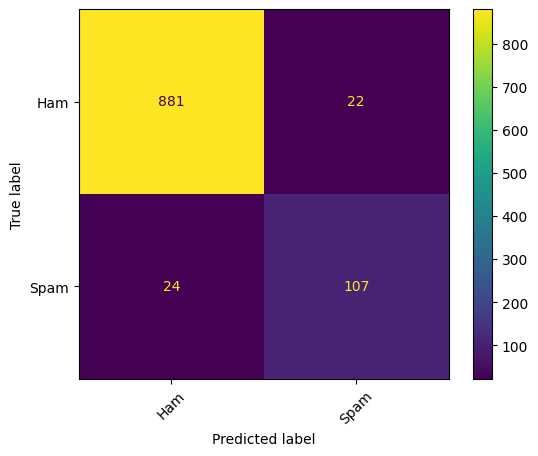

In [347]:
ConfusionMatrixDisplay.from_estimator(gb_model,
                                       X_test,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Ham', 'Spam']
    );

#### Xgboost

In [348]:
xgboost = model = XGBClassifier(objective = "binary:logistic" , subsample = 0.7 , min_child_weight = 3,
                                max_depth = 3 , learning_rate = 0.1 , gamma = 0 , colsample_bytree = 0.5,)
train(xgboost,"Xgboost", X_train, y_train, X_test, y_test)
class_report(xgboost, X_test, y_test)

Xgboost model score on Training data: 98.58843066703571%
Xgboost model score on Testing data: 96.61508704061895%
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       903
        Spam       0.92      0.80      0.86       131

    accuracy                           0.97      1034
   macro avg       0.95      0.90      0.92      1034
weighted avg       0.97      0.97      0.97      1034



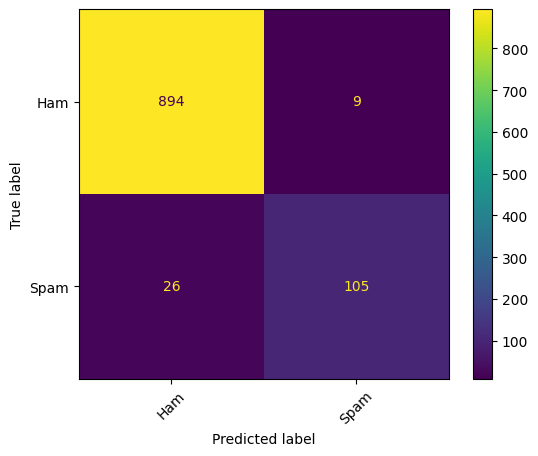

In [349]:
ConfusionMatrixDisplay.from_estimator(xgboost,
                                       X_test,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Ham', 'Spam']
    );